# Optimización local: el problema de las 4 reinas

En este ejercicio modelaremos el problema de las **4 reinas** como un problema de optimización y construiremos tres algoritmos:

1. **Hill Climbing**
2. **Hill Climbing con Random Restart**
3. **Simulated Annealing**

La mayor parte de las funciones están incompletas. Deben implementarse durante la clase.

---

## Objetivo

Ubicar cuatro reinas en un tablero $4 \times 4$ de forma que ninguna pareja se ataque.

Una reina ataca a otra si ambas están:

- en la misma fila;
- en la misma columna;
- en la misma diagonal.

## 1. Formulación como problema de optimización

Representaremos un estado mediante un vector:

$$
x = [x_0, x_1, x_2, x_3]
$$

donde $x_i$ indica la **fila** de la reina ubicada en la columna $i$.

Por ejemplo:

$$
x = [1, 3, 0, 2]
$$

representa las posiciones:

$$
(1,0), (3,1), (0,2), (2,3)
$$

Como cada columna contiene exactamente una reina, no pueden existir conflictos por columna.

### Espacio de búsqueda

Cada una de las cuatro reinas puede estar en cualquiera de las cuatro filas:

$$
|\mathcal{X}| = 4^4 = 256
$$

### Función de costo

Definiremos:

$$
C(x) = \text{número de parejas de reinas que se atacan}
$$

El objetivo es resolver:

$$
\min_{x \in \mathcal{X}} C(x)
$$

Una solución válida satisface:

$$
C(x)=0
$$

In [1]:
import math
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#F0D9B5", "#B58863"])



N = 4
SEED = 42
random.seed(SEED)

## 2. Visualización de un estado

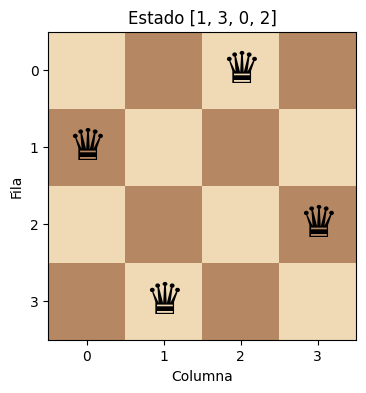

In [2]:
def plot_board(state, title=None):
    """Visualiza un estado del problema de las N reinas."""
    n = len(state)
    board = [[(row + col) % 2 for col in range(n)] for row in range(n)]

    plt.figure(figsize=(4, 4))
    plt.imshow(board, cmap="Greys", vmin=0, vmax=1)

    for col, row in enumerate(state):
        plt.text(col, row, "♛", ha="center", va="center", fontsize=32)

    plt.xticks(range(n))
    plt.yticks(range(n))
    plt.xlabel("Columna")
    plt.ylabel("Fila")
    plt.grid(False)
    if title:
        plt.title(title)

    plt.imshow(board, cmap=cmap)


example_state = [1, 3, 0, 2]
plot_board(example_state, title=f"Estado {example_state}")

## Actividad 1. Detectar conflictos

Dos reinas ubicadas en $(r_i,c_i)$ y $(r_j,c_j)$ se atacan si:

$$
r_i = r_j
$$

o si están en la misma diagonal:

$$
|r_i-r_j| = |c_i-c_j|
$$

Complete la función `attacking`.

In [3]:
def attacking(row_i, col_i, row_j, col_j):
    return row_i == row_j or col_i == col_j or abs(row_i - row_j) == abs(col_i - col_j)

In [4]:
# Pruebas de la actividad 1
assert attacking(0, 0, 0, 3) is True       # misma fila
assert attacking(0, 0, 3, 3) is True       # misma diagonal
assert attacking(0, 0, 1, 3) is False      # no se atacan

print("Pruebas superadas.")

Pruebas superadas.


## Actividad 2. Función de costo

Implemente una función que cuente cuántas parejas de reinas se atacan.

Para cuatro reinas existen:

$$
\binom{4}{2}=6
$$

parejas posibles.

In [5]:
def cost(state):
    n = len(state)
    attacked=0

    for i in range(n):
        for j in range(i + 1, n):
            if attacking(state[i], i, state[j], j):
                attacked += 1
    return attacked


In [6]:
# Pruebas de la actividad 2
assert cost([0, 0, 0, 0]) == 6
assert cost([0, 1, 2, 3]) == 6
assert cost([1, 3, 0, 2]) == 0

print("Pruebas superadas.")

Pruebas superadas.


## 3. Vecindario

Un vecino se obtiene moviendo **una sola reina** a otra fila de su misma columna.

Para cada una de las $N$ columnas hay $N-1$ movimientos posibles:

$$
|N(x)| = N(N-1)
$$

Para $N=4$:

$$
|N(x)|=4(3)=12
$$

## Actividad 3. Generar los vecinos

Implemente `neighbors(state)`.

La función debe retornar todos los estados que difieren del original en la fila de exactamente una reina.

In [7]:
def neighbors(state):
    n = len(state)
    neighbor_states = []

    for col in range(n):
        for row in range(n):
            if row != state[col]:  
                new_state = state.copy()
                new_state[col] = row
                neighbor_states.append(new_state)

    return neighbor_states

In [8]:
# Pruebas de la actividad 3
test_state = [0, 1, 2, 3]
test_neighbors = neighbors(test_state)

assert len(test_neighbors) == 12
assert test_state not in test_neighbors
assert len({tuple(s) for s in test_neighbors}) == 12

print("Pruebas superadas.")

Pruebas superadas.


## Actividad 4. Mejor vecino

Implemente una función que encuentre el menor costo entre todos los vecinos.

Cuando existan varios vecinos con el mismo costo mínimo, seleccione uno aleatoriamente.

In [9]:
def best_neighbor(state):
    neighbor_states=neighbors(state)
    best_state=None
    best_cost=math.inf

    for neighbor in neighbor_states:
        neighbor_cost=cost(neighbor)
        if neighbor_cost<best_cost:
            best_cost=neighbor_cost
            best_state=neighbor

    return best_state, best_cost     

In [10]:
# Prueba básica
state = [0, 0, 0, 0]
next_state, next_cost = best_neighbor(state)

assert next_state in neighbors(state)
assert next_cost == cost(next_state)
assert next_cost == min(cost(s) for s in neighbors(state))

print("Pruebas superadas.")

Pruebas superadas.


## 4. Hill Climbing

Hill Climbing comienza en un estado inicial y se mueve repetidamente hacia un vecino con menor costo.

$$
x_{t+1} = \arg\min_{y \in N(x_t)} C(y)
$$

El algoritmo termina cuando:

- encuentra una solución con costo cero; o
- ningún vecino mejora el estado actual.

Este segundo caso puede corresponder a un **mínimo local** o a una **meseta**.

## Actividad 5. Implementar Hill Climbing

In [11]:
def hill_climbing(initial_state, max_steps=100):
    current_state = initial_state.copy()
    current_cost = cost(current_state)
    history = [current_state.copy()]

    for step in range(max_steps):
        next_state, next_cost = best_neighbor(current_state)

        if next_cost >= current_cost:
            break

        current_state = next_state
        current_cost = next_cost
        history.append(current_state.copy())

    return current_state, history


Estado inicial: [0, 0, 0, 0]
Estado final: [1, 3, 0, 2]
Costo final: 0
Número de movimientos: 3


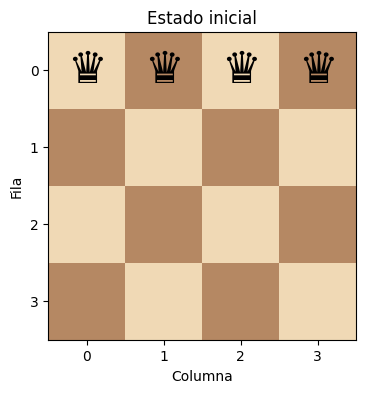

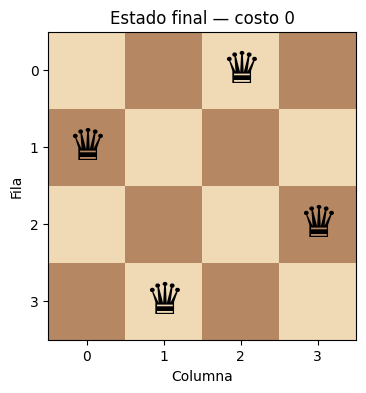

In [12]:
initial_state = [0, 0, 0, 0]
final_state, history = hill_climbing(initial_state)

print("Estado inicial:", initial_state)
print("Estado final:", final_state)
print("Costo final:", cost(final_state))
print("Número de movimientos:", len(history) - 1)

plot_board(initial_state, "Estado inicial")
plot_board(final_state, f"Estado final — costo {cost(final_state)}")

## Actividad 6. Analizar una ejecución

Grafique el costo de los estados visitados por Hill Climbing.

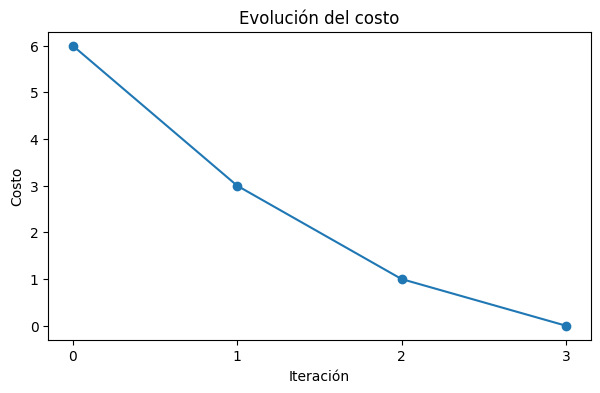

In [13]:
def plot_cost_history(history, title="Evolución del costo"):
    costs = [cost(state) for state in history]

    plt.figure(figsize=(7, 4))
    plt.plot(range(len(costs)), costs, marker="o")
    plt.xlabel("Iteración")
    plt.ylabel("Costo")
    plt.title(title)
    plt.xticks(range(len(costs)))
    plt.show()


plot_cost_history(history)

## 5. Hill Climbing con Random Restart

Hill Climbing puede quedar atrapado en mínimos locales.

Random Restart ejecuta Hill Climbing desde diferentes estados iniciales:

$$
x_0^{(1)}, x_0^{(2)}, \ldots, x_0^{(R)}
$$

El algoritmo termina cuando encuentra una solución o cuando agota el número máximo de reinicios.

## Actividad 7. Implementar Random Restart

In [14]:
def random_state(n=N):
    return [random.randrange(n) for _ in range(n)]


def random_restart_hill_climbing(max_restarts=50, max_steps=100):
    best_state = None
    best_cost = math.inf
    best_history = None

    for restart in range(1, max_restarts + 1):
        initial_state = random_state()
        final_state, history = hill_climbing(initial_state, max_steps=max_steps)
        final_cost = cost(final_state)

        if final_cost < best_cost:
            best_state = final_state
            best_cost = final_cost
            best_history = history

        if best_cost == 0:
            break

    return best_state, best_history, restart


Mejor estado: [1, 3, 0, 2]
Costo: 0
Reinicios utilizados: 2


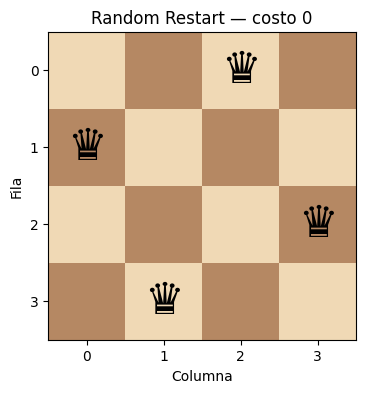

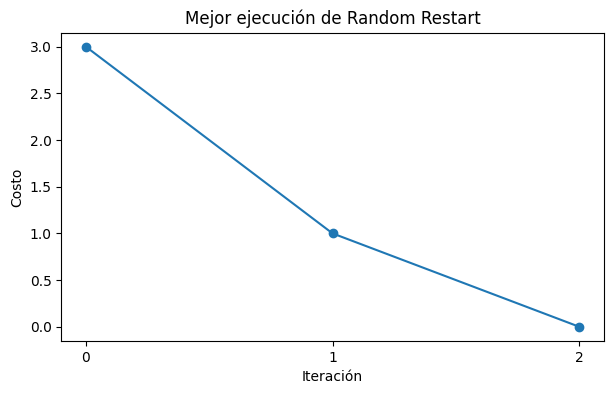

In [15]:
best_state, best_history, restarts = random_restart_hill_climbing()

print("Mejor estado:", best_state)
print("Costo:", cost(best_state))
print("Reinicios utilizados:", restarts)

plot_board(best_state, f"Random Restart — costo {cost(best_state)}")
plot_cost_history(best_history, "Mejor ejecución de Random Restart")

## 6. Simulated Annealing

Simulated Annealing permite aceptar temporalmente movimientos que empeoran la solución.

Si un vecino tiene costo menor o igual, se acepta.

Si empeora el costo en una cantidad:

$$
\Delta C = C(x') - C(x) > 0
$$

se acepta con probabilidad:

$$
P(\text{aceptar}) = e^{-\Delta C/T}
$$

donde $T$ es la temperatura.

Usaremos un enfriamiento geométrico:

$$
T_{t+1} = \alpha T_t
$$

con $0 < \alpha < 1$.

## Actividad 8. Probabilidad de aceptación

In [16]:
def acceptance_probability(current_cost, candidate_cost, temperature):
    if candidate_cost <= current_cost:
        return 1.0
    delta = candidate_cost - current_cost
    return math.exp(-delta / temperature)


In [17]:
assert acceptance_probability(3, 2, 1.0) == 1.0
assert acceptance_probability(3, 3, 1.0) == 1.0

p = acceptance_probability(2, 3, 1.0)
assert math.isclose(p, math.exp(-1), rel_tol=1e-9)

print("Pruebas superadas.")

Pruebas superadas.


## Actividad 9. Implementar Simulated Annealing

En cada iteración:

1. seleccione un vecino aleatorio;
2. calcule el cambio de costo;
3. acepte siempre las mejoras;
4. acepte algunos movimientos peores según la temperatura;
5. reduzca la temperatura.

In [18]:
def simulated_annealing(
    initial_state,
    initial_temperature=10.0,
    cooling_rate=0.95,
    min_temperature=1e-3,
    max_steps=1000,
):
    current_state = initial_state.copy()
    current_cost = cost(current_state)

    best_state = current_state.copy()
    best_cost = current_cost

    history = [current_state.copy()]
    temperatures = [initial_temperature]

    temperature = initial_temperature

    for step in range(max_steps):
        if current_cost == 0 or temperature < min_temperature:
            break

        candidate = random.choice(neighbors(current_state))
        candidate_cost = cost(candidate)

        if random.random() < acceptance_probability(current_cost, candidate_cost, temperature):
            current_state = candidate
            current_cost = candidate_cost

            history.append(current_state.copy())
            temperatures.append(temperature)

            if current_cost < best_cost:
                best_state = current_state.copy()
                best_cost = current_cost

        temperature *= cooling_rate

    return best_state, history, temperatures


Estado inicial: [3, 0, 0, 0]
Mejor estado: [2, 0, 3, 1]
Costo final: 0
Estados aceptados: 53


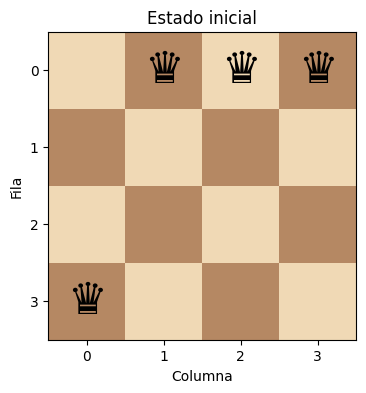

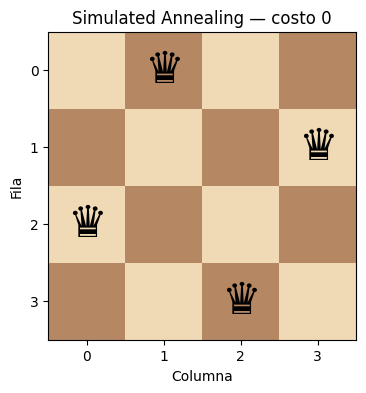

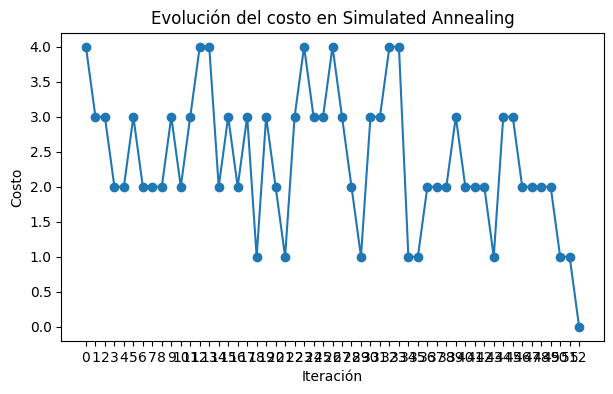

In [19]:
initial_state = random_state()
sa_state, sa_history, temperatures = simulated_annealing(initial_state)

print("Estado inicial:", initial_state)
print("Mejor estado:", sa_state)
print("Costo final:", cost(sa_state))
print("Estados aceptados:", len(sa_history))

plot_board(initial_state, "Estado inicial")
plot_board(sa_state, f"Simulated Annealing — costo {cost(sa_state)}")
plot_cost_history(sa_history, "Evolución del costo en Simulated Annealing")

## Actividad 10. Comparación experimental

Ejecute cada algoritmo varias veces y registre su tasa de éxito.

Una ejecución es exitosa cuando encuentra un estado con costo cero.

In [20]:
def compare_algorithms(trials=100):
    results = {
        "Hill Climbing": 0,
        "Random Restart": 0,
        "Simulated Annealing": 0,
    }

    for _ in range(trials):
        initial_state = random_state()

        hc_state, _ = hill_climbing(initial_state)
        if cost(hc_state) == 0:
            results["Hill Climbing"] += 1

        rr_state, _, _ = random_restart_hill_climbing(max_restarts=20)
        if cost(rr_state) == 0:
            results["Random Restart"] += 1

        sa_state, _, _ = simulated_annealing(initial_state)
        if cost(sa_state) == 0:
            results["Simulated Annealing"] += 1

    return results


results = compare_algorithms(trials=100)
for algorithm, successes in results.items():
    print(f"{algorithm:20s}: {successes}/100")


Hill Climbing       : 35/100
Random Restart      : 100/100
Simulated Annealing : 99/100


## Preguntas de discusión

## Respuestas

**1. ¿Por qué Hill Climbing puede fallar aunque exista una solución?**

Hill Climbing solo acepta un vecino si reduce el costo. Puede detenerse cuando el mejor vecino tiene un costo igual o mayor, aunque exista una solución de costo cero en otra región. En la comparación para cuatro reinas encontró soluciones en `36/100` ejecuciones; falló en las otras `64`.

**2. ¿Qué diferencia existe entre una meseta y un mínimo local?**

En un mínimo local no hay vecinos con menor costo, aunque exista un estado mejor más lejos. En una meseta, varios vecinos tienen el mismo costo. En esta implementación ambas situaciones provocan la parada porque la condición es `next_cost >= current_cost`, así que no se permiten movimientos laterales con igual costo. La ejecución desde `[0, 0, 0, 0]` alcanzó `[1, 3, 0, 2]` con costo `0` en 3 movimientos.

**3. ¿Por qué Random Restart mejora la probabilidad de encontrar una solución?**

Cada reinicio comienza desde un estado diferente. Si una ejecución cae en un mínimo local, otra puede iniciar en una región que conduzca a una solución. En la comparación de cuatro reinas obtuvo `100/100` éxitos, frente a `36/100` de Hill Climbing. En el ejemplo individual encontró costo `0` después de `2` reinicios.

**4. ¿Qué ocurre en Simulated Annealing cuando la temperatura es muy alta?**

La probabilidad de aceptar un movimiento peor es:

$$
P(aceptar)=e^{-\Delta C/T}
$$

Cuando $T$ aumenta, se aceptan más movimientos peores, lo que favorece la exploración y permite escapar de mínimos locales. En ocho reinas, las temperaturas iniciales obtuvieron: `1.0: 9/30`, `5.0: 8/30`, `10.0: 9/30`, `20.0: 5/30` y `50.0: 10/30`. No hubo crecimiento monotónico, así que una temperatura alta favorece la exploración, pero no garantiza más éxitos.

**5. ¿Qué ocurre si la temperatura disminuye demasiado rápido?**

Simulated Annealing deja de aceptar movimientos peores casi inmediatamente y se comporta como Hill Climbing, reduciendo su capacidad de escapar de mínimos locales. En ocho reinas, las tasas obtuvieron: `0.80: 1/30`, `0.90: 2/30`, `0.95: 5/30`, `0.97: 11/30` y `0.99: 15/30`. Para esta configuración, un enfriamiento más gradual produjo más éxitos.

**6. ¿Cómo cambiaría el tamaño del espacio de búsqueda para 8 reinas?**

Con una reina por columna, el espacio es $N^N$. Para cuatro reinas es $4^4=256$ y para ocho es $8^8=16\,777\,216$. El vecindario pasa de $4(4-1)=12$ a $8(8-1)=56$ movimientos. En el reto de ocho reinas, Hill Climbing obtuvo `3/50`, Random Restart `50/50` y Simulated Annealing `9/50`.

**7. ¿Cuál de los tres algoritmos fue más confiable en los experimentos?**

Para cuatro reinas, Random Restart y Simulated Annealing obtuvieron `100/100`, mientras Hill Climbing obtuvo `36/100`. Para ocho reinas, Random Restart obtuvo `50/50`, Simulated Annealing `9/50` y Hill Climbing `3/50`. Por lo tanto, en las ejecuciones de este notebook Random Restart fue el más confiable.


## Reto adicional

Modifique:

```python
N = 8
```

y evalúe los algoritmos en el problema de las **8 reinas**.

Compare:

- tasa de éxito;
- número de iteraciones;
- número de reinicios;
- sensibilidad a la temperatura inicial;
- sensibilidad a la tasa de enfriamiento.

In [21]:
N = 8
random.seed(SEED)


def random_state(n=N):
    return [random.randrange(n) for _ in range(n)]


### Tasa de éxito, iteraciones y reinicios para N = 8

In [22]:
def run_n8_experiment(trials=50):
    hc_successes = 0
    hc_iterations = []

    rr_successes = 0
    rr_restarts = []

    sa_successes = 0
    sa_iterations = []

    for _ in range(trials):
        initial_state = random_state()

        hc_state, hc_history = hill_climbing(initial_state, max_steps=200)
        hc_iterations.append(len(hc_history) - 1)
        if cost(hc_state) == 0:
            hc_successes += 1

        rr_state, _, rr_used = random_restart_hill_climbing(max_restarts=50, max_steps=200)
        rr_restarts.append(rr_used)
        if cost(rr_state) == 0:
            rr_successes += 1

        sa_state, sa_history, _ = simulated_annealing(
            initial_state,
            initial_temperature=20.0,
            cooling_rate=0.97,
            max_steps=2000,
        )
        sa_iterations.append(len(sa_history) - 1)
        if cost(sa_state) == 0:
            sa_successes += 1

    print(f"Hill Climbing       : {hc_successes}/{trials} éxitos, {sum(hc_iterations)/trials:.1f} iteraciones promedio")
    print(f"Random Restart       : {rr_successes}/{trials} éxitos, {sum(rr_restarts)/trials:.1f} reinicios promedio")
    print(f"Simulated Annealing  : {sa_successes}/{trials} éxitos, {sum(sa_iterations)/trials:.1f} iteraciones promedio")


run_n8_experiment(trials=50)


Hill Climbing       : 3/50 éxitos, 2.9 iteraciones promedio
Random Restart       : 50/50 éxitos, 6.8 reinicios promedio
Simulated Annealing  : 9/50 éxitos, 111.1 iteraciones promedio


### Sensibilidad a la temperatura inicial

In [23]:
def sensitivity_initial_temperature(temperatures, trials=30):
    for T0 in temperatures:
        successes = 0
        for _ in range(trials):
            initial_state = random_state()
            sa_state, _, _ = simulated_annealing(
                initial_state,
                initial_temperature=T0,
                cooling_rate=0.97,
                max_steps=2000,
            )
            if cost(sa_state) == 0:
                successes += 1
        print(f"T0 = {T0:5.1f}: {successes}/{trials} éxitos")


sensitivity_initial_temperature([1.0, 5.0, 10.0, 20.0, 50.0])


T0 =   1.0: 9/30 éxitos
T0 =   5.0: 8/30 éxitos
T0 =  10.0: 9/30 éxitos
T0 =  20.0: 5/30 éxitos
T0 =  50.0: 10/30 éxitos


### Sensibilidad a la tasa de enfriamiento

In [24]:
def sensitivity_cooling_rate(rates, trials=30):
    for rate in rates:
        successes = 0
        for _ in range(trials):
            initial_state = random_state()
            sa_state, _, _ = simulated_annealing(
                initial_state,
                initial_temperature=20.0,
                cooling_rate=rate,
                max_steps=2000,
            )
            if cost(sa_state) == 0:
                successes += 1
        print(f"cooling_rate = {rate:.2f}: {successes}/{trials} éxitos")


sensitivity_cooling_rate([0.80, 0.90, 0.95, 0.97, 0.99])


cooling_rate = 0.80: 1/30 éxitos
cooling_rate = 0.90: 2/30 éxitos
cooling_rate = 0.95: 5/30 éxitos
cooling_rate = 0.97: 11/30 éxitos
cooling_rate = 0.99: 15/30 éxitos
